In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/datasets/house-prices-uk/master/data/data.csv"
df = pd.read_csv(url)

# Preview
df.head()

,Date,Price (All),Change (All),Price (New),Change (New),Price (Modern),Change (Modern),Price (Older),Change (Older)
0,1953-02-01,1891.0,NaN,2107.0,NaN,2002.0,NaN,1542.0,NaN
1,1953-05-01,1891.0,NaN,2107.0,NaN,2002.0,NaN,1542.0,NaN
2,1953-08-01,1881.0,NaN,2117.0,NaN,2002.0,NaN,1524.0,NaN
3,1953-11-01,1872.0,-1.0,2117.0,0.5,1975.0,-2.2,1542.0,1.2
4,1954-02-01,1863.0,-1.5,2117.0,0.5,1957.0,-2.2,1524.0,-1.2


In [5]:
print(df.columns)

Index(['Date', 'Price (All)', 'Change (All)', 'Price (New)', 'Change (New)',
       'Price (Modern)', 'Change (Modern)', 'Price (Older)', 'Change (Older)'],
      dtype='object')


In [6]:
# Drop columns with > 40% missing data
missing_threshold = 0.4
df = df.loc[:, df.isnull().mean() < missing_threshold]

# Fill numerical missing values with median (prevents outlier bias)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Handle categorical missing values with the mode
cat_cols = df.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Cap outliers in price at 99th percentile
upper_limit = df['Price (All)'].quantile(0.99)
df = df[df['Price (All)'] < upper_limit]

In [8]:
# Create meaningful metrics
if 'Price (All)' in df.columns and 'size_sqft' in df.columns:
    df['PricePerSqFt'] = df['Price (All)'] / df['size_sqft']

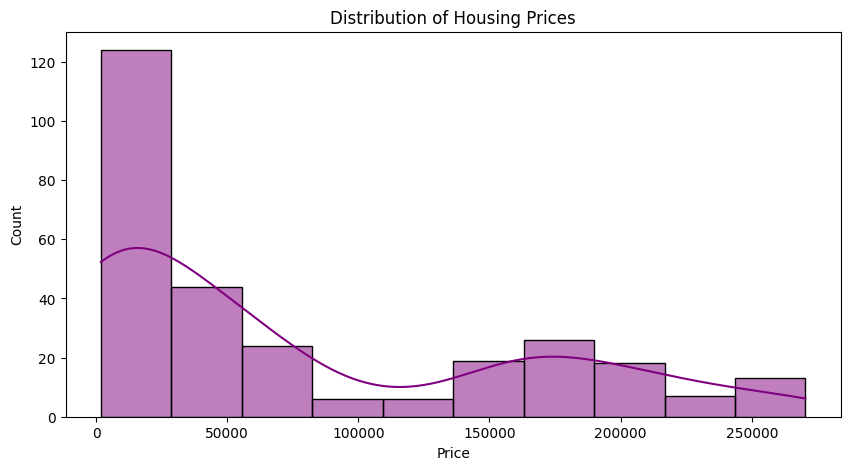

In [9]:
# 1. Price Distribution (Histplot)
plt.figure(figsize=(10, 5))
sns.histplot(df['Price (All)'], kde=True, color='purple')
plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.show()

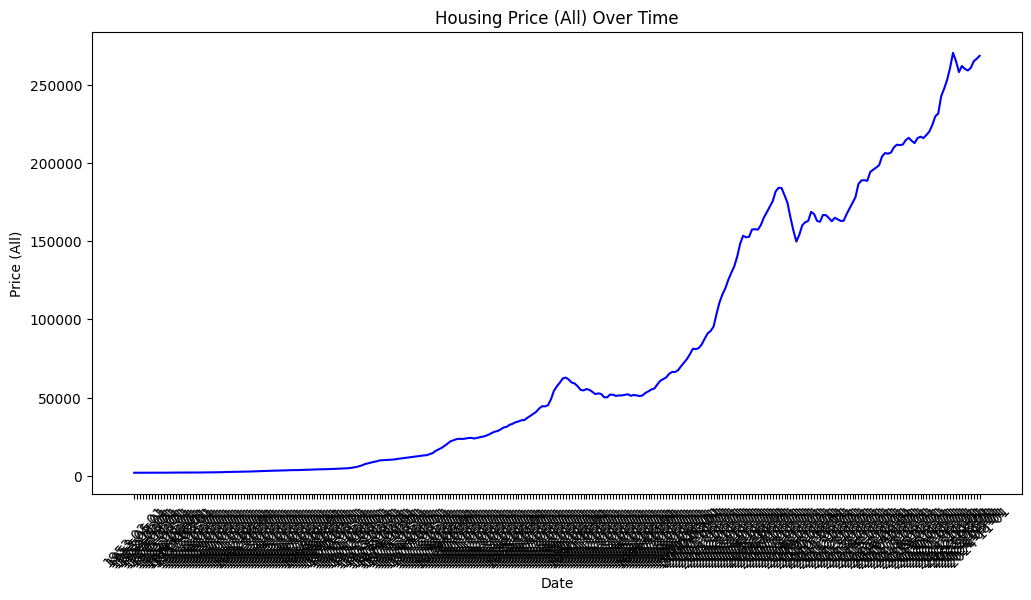

In [15]:
# Price Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Price (All)', data=df, color='blue')
plt.title("Housing Price (All) Over Time")
plt.xticks(rotation=45) # Rotates dates so they don't overlap
plt.show()

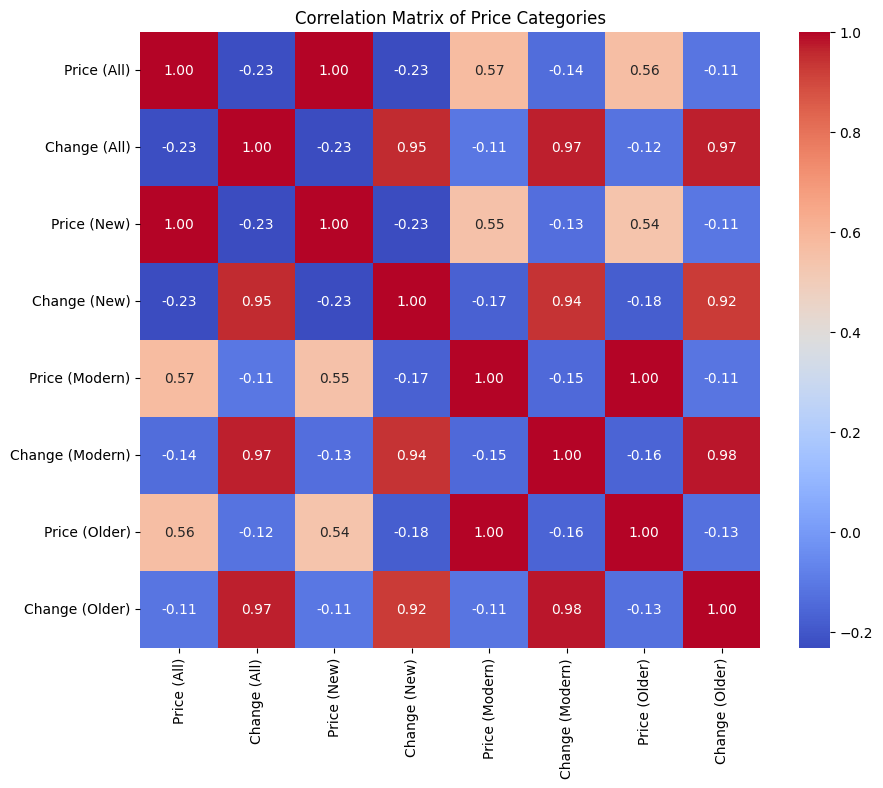

In [16]:
# 2. Correlation Heatmap
# This will show how the different price categories correlate with each other
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Price Categories")
plt.show()

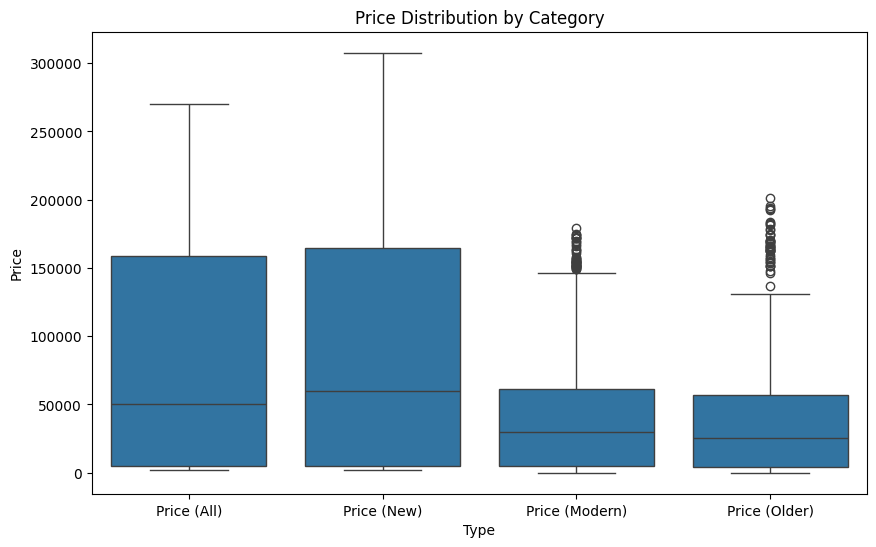

In [17]:
# 3. Price Category Comparison (Boxplot)
# This compares the distribution of the different price types
plt.figure(figsize=(10, 6))
# We melt the data to make it easier for seaborn to plot multiple categories
df_melted = df.melt(value_vars=['Price (All)', 'Price (New)', 'Price (Modern)', 'Price (Older)'], var_name='Type', value_name='Price')
sns.boxplot(x='Type', y='Price', data=df_melted)
plt.title("Price Distribution by Category")
plt.show()